# 02 — Análise de Resultados dos Modelos

Este notebook **não re-treina os modelos**. Ele carrega os artefatos já gerados pelo script `src/train.py` e apresenta os resultados de forma visual e analítica.

**Pré-requisito:** rode `python src/train.py` na raiz do projeto antes de executar este notebook.

---

O pipeline de treinamento avalia três modelos:
- **Logistic Regression** — modelo linear probabilístico
- **Random Forest** — ensemble de 200 árvores de decisão
- **SVM** — busca o hiperplano de máxima margem entre as classes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Comparação de desempenho entre os modelos

O arquivo `reports/model_comparison.csv` é gerado automaticamente pelo `train.py` e contém as métricas de cada modelo:

- **accuracy** — porcentagem de acertos no conjunto de teste
- **auc** — área sob a curva ROC (1.0 = perfeito, 0.5 = aleatório)
- **cv_mean** — média de acurácia em 5 rodadas de validação cruzada
- **cv_std** — desvio padrão entre as 5 rodadas (menor = mais estável)

In [2]:
results_df = pd.read_csv("../reports/model_comparison.csv")
results_df.style.format({
    "accuracy": "{:.2%}",
    "auc": "{:.4f}",
    "cv_mean": "{:.2%}",
    "cv_std": "{:.4f}"
}).background_gradient(subset=["accuracy", "auc", "cv_mean"], cmap="Greens")

,model,accuracy,auc,cv_mean,cv_std
0,logistic_regression,98.25%,0.9954,98.07%,0.0065
1,svm,98.25%,0.9950,97.36%,0.0147
2,random_forest,95.61%,0.9931,95.78%,0.0238


## Curvas ROC

A **curva ROC** (Receiver Operating Characteristic) mostra o desempenho do modelo em todos os possíveis limiares de decisão. O eixo X representa a taxa de falsos positivos e o eixo Y a taxa de verdadeiros positivos (sensibilidade).

A **AUC** (área sob a curva) resume esse desempenho em um único número: quanto mais próxima de 1.0, melhor o modelo consegue separar as classes.

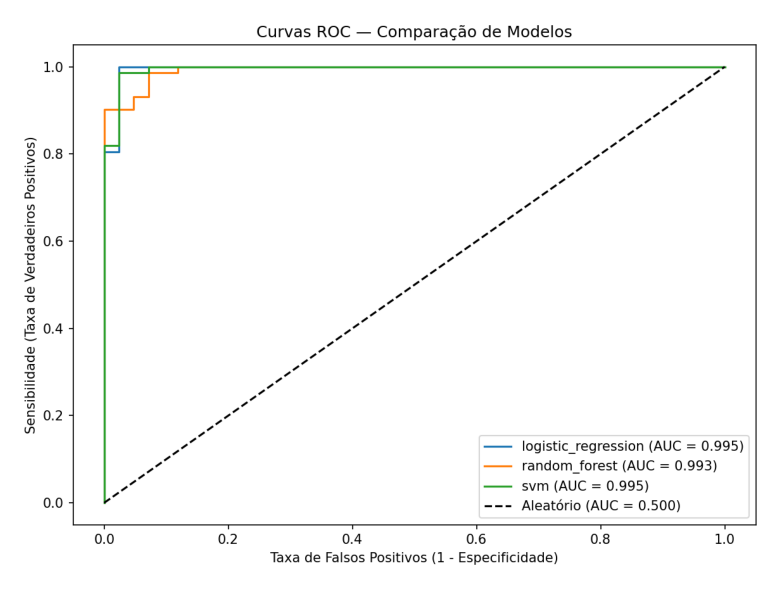

In [3]:
img = mpimg.imread("../figures/roc_curves.png")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## Feature Importance

### Random Forest
A Random Forest calcula automaticamente a **importância de cada feature** com base em quanto ela contribuiu para reduzir a incerteza nas decisões das 200 árvores. Features usadas no topo das árvores e com maior frequência recebem maior pontuação.

### Regressão Logística
Os **coeficientes** da Regressão Logística indicam o peso de cada feature na decisão final. Coeficientes negativos empurram a predição para maligno; positivos, para benigno. Como os dados foram normalizados antes do treino, os coeficientes são comparáveis entre si.

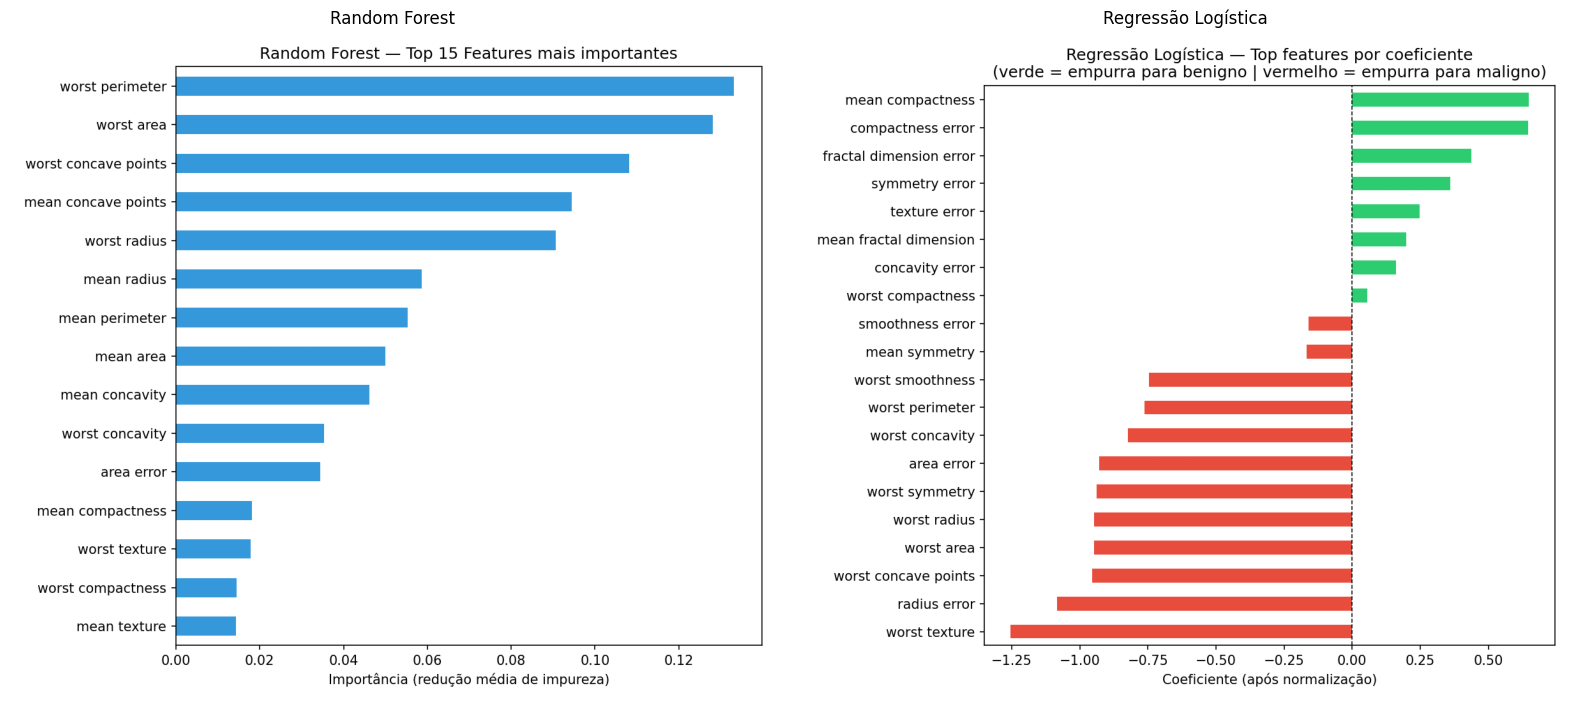

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fname, title in [
    (axes[0], "../figures/feature_importance_rf.png", "Random Forest"),
    (axes[1], "../figures/feature_importance_lr.png", "Regressão Logística"),
]:
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## Conclusão

Com base nos resultados:

- **Regressão Logística** foi o modelo mais eficaz neste dataset: acurácia de **98.2%**, AUC de **0.995** e menor variação entre as rodadas de validação cruzada (cv_std = 0.0065)
- O **SVM** alcançou a mesma acurácia, mas com maior instabilidade entre rodadas (cv_std = 0.0147)
- O **Random Forest** ficou abaixo dos outros dois, o que faz sentido: o dataset é bem separável linearmente, cenário que favorece modelos lineares

As features mais relevantes para o diagnóstico foram consistentemente as relacionadas à **forma e tamanho do pior núcleo** observado: `worst concave points`, `worst perimeter` e `worst radius`. Isso tem correspondência com o conhecimento clínico — tumores malignos tendem a ter células com bordas irregulares e núcleos maiores.